<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span><ul class="toc-item"><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Загрузка данных</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Изучим-общую-информацию-о-датафреймах" data-toc-modified-id="Изучим-общую-информацию-о-датафреймах-1.2.1"><span class="toc-item-num">1.2.1&nbsp;&nbsp;</span>Изучим общую информацию о датафреймах</a></span></li><li><span><a href="#Проверим-наличие-пропусков-в-данных" data-toc-modified-id="Проверим-наличие-пропусков-в-данных-1.2.2"><span class="toc-item-num">1.2.2&nbsp;&nbsp;</span>Проверим наличие пропусков в данных</a></span></li><li><span><a href="#Проверим-данные-на-наличие-дубликатов" data-toc-modified-id="Проверим-данные-на-наличие-дубликатов-1.2.3"><span class="toc-item-num">1.2.3&nbsp;&nbsp;</span>Проверим данные на наличие дубликатов</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span></li></ul></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Подготовка данных</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Модель-LogisticRegression()" data-toc-modified-id="Модель-LogisticRegression()-2.2.1"><span class="toc-item-num">2.2.1&nbsp;&nbsp;</span>Модель LogisticRegression()</a></span></li><li><span><a href="#Модель-DecisionTreeClassifier()" data-toc-modified-id="Модель-DecisionTreeClassifier()-2.2.2"><span class="toc-item-num">2.2.2&nbsp;&nbsp;</span>Модель DecisionTreeClassifier()</a></span></li><li><span><a href="#Модель-LGBMClassifier()" data-toc-modified-id="Модель-LGBMClassifier()-2.2.3"><span class="toc-item-num">2.2.3&nbsp;&nbsp;</span>Модель LGBMClassifier()</a></span></li><li><span><a href="#Модель-RandomForestClassifier()" data-toc-modified-id="Модель-RandomForestClassifier()-2.2.4"><span class="toc-item-num">2.2.4&nbsp;&nbsp;</span>Модель RandomForestClassifier()</a></span></li></ul></li><li><span><a href="#Анализ-лучшей-модели" data-toc-modified-id="Анализ-лучшей-модели-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Анализ лучшей модели</a></span></li><li><span><a href="#Тестирование-лучшей-выбранной-модели" data-toc-modified-id="Тестирование-лучшей-выбранной-модели-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Тестирование лучшей выбранной модели</a></span></li></ul></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Выводы</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75. 

**Инструкция по выполнению проекта**

1. Загрузите и подготовьте данные.
2. Обучите разные модели. 
3. Сделайте выводы.

Для выполнения проекта применять *BERT* необязательно, но вы можете попробовать.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

**Импортируем и установим все необходимые библиотеки для исследования:**

(некоторые библиотеки могут установиться не с первого раза)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import re
from tqdm.notebook import tqdm
tqdm.pandas()
from pymystem3 import Mystem
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
nltk.download('averaged_perceptron_tagger')
from sklearn.feature_extraction.text import TfidfVectorizer
import time
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import f1_score
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.3

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


## Подготовка

### Загрузка данных

Считаем CSV-файл с данными с помощью библиотеки pandas и сохраним в датафрейм.

In [2]:
df_comments = pd.read_csv('/datasets/toxic_comments.csv')

Выведем первые строки датафрейма, чтобы проверить, правильно ли считались данные:

In [3]:
df_comments.head()

,Unnamed: 0,text,toxic
0,0,Explanation\nWhy the edits made under my usern...,0
1,1,D'aww! He matches this background colour I'm s...,0
2,2,"Hey man, I'm really not trying to edit war. It...",0
3,3,"""\nMore\nI can't make any real suggestions on ...",0
4,4,"You, sir, are my hero. Any chance you remember...",0


Из вывода видем, что столбец `'Unnamed: 0'` скорее всего случайно попал при выгрузке комментариев, и просто является копией индекса строки датафрейма, поэтому удалим этот столбец, как неинформативный.

In [4]:
del(df_comments['Unnamed: 0'])

Повторно выведем первые строки после удаления:

In [5]:
df_comments.head()

,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


Теперь можно говорить о том, что CSV-файл считался правильно, и с ним можно работать.

### Предобработка данных

Изучим данные и сделаем выводы. 

#### Изучим общую информацию о датафреймах

Теперь для лучшего понимания данных, хранящихся в датафрейме, выведем информацию о нем методом `.info()`:

In [6]:
df_comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


Выведем размеры датафрейма:

In [7]:
df_comments.shape

(159292, 2)

Из общей информации по датафрему можно говорить о том, что данные в столбцах и их тип соответствуют действительности, и изменять ничего не нужно.

#### Проверим наличие пропусков в данных

Из вывода общей информации заметно, что есть пропуски в данных.

Воспользуемся методом `.isna()` для поиска пропусков во всех датафреймах и просуммируем их методом `.sum()`:

In [8]:
df_comments.isna().sum()

text     0
toxic    0
dtype: int64

Из результатов вывода видно, что пропущенных значений нет. Это является *очень хорошим* показателем.

#### Проверим данные на наличие дубликатов

После проверки датафреймов на наличие пропусков, проверим их на наличие дубликатов:

Воспользуемся методом `.duplicated()`, чтобы найти *явные* дубликаты в датафрейме и после методом `.sum()` выведем их количество:

In [9]:
df_comments.duplicated().sum()

0

В результате наблюдаем, что *явных* дубликатов нет.

Проверку на *неявные* дубликаты проводить нет необходимости, так как комментарии скорее всего точно отличаются друг от друга, и мы просто получим такой же результат на более 150 тысяч данных.

### Исследовательский анализ данных

Исследуем признаки и сделаем выводы о том, как их нужно подготовить.


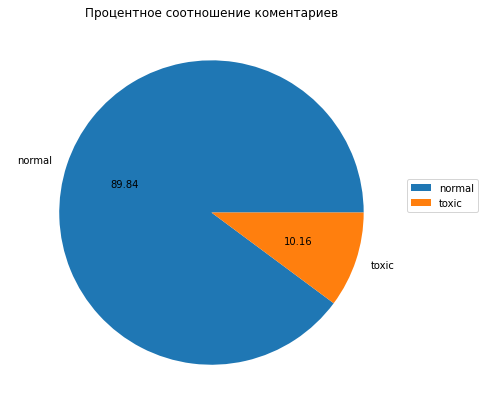

0    143106
1     16186
Name: toxic, dtype: int64


In [10]:
plt.figure(figsize=(10, 7))
df_comments['toxic'].value_counts().plot(kind='pie', autopct='%.2f', labels=['normal','toxic'])
plt.ylabel(' ')
plt.title('Процентное соотношение коментариев')
plt.legend(bbox_to_anchor=(1, 0.6))
plt.show()
print(df_comments['toxic'].value_counts())

Из диаграммы видим сильный диссбаланс данных. В связи с этим при обучении и поиске наилучшей модели учтём данную вещь. 

**Промежуточный вывод:**

В результате подготовки данных были выполнены следующие шаги:
- загрузили CSV-файл и проверили корректность его отображения
- изучили основную информацию о датафрейме
- определили, что тип данных соответствует действительности
- проверили данные на пропуски - выяснили, что они отсутствуют
- проверили и проанализировали данные на наличие дубликатов - выявили, что их нет
- выявили диссбаланс классов, поэтому учтём это при обучении моделей

## Обучение

### Подготовка данных

Из вывода ранее мы заметили, что в столбце `text` датафрейма присутствует "мусор" - лишние разделительные символы, специальные символы и прочее. Очистим наши данные от этого путем написания функции `clear_text()`, в ней же приведем все заглавные буквы текста к строковым: 

In [11]:
def clear_text(text):
    text = re.sub(r"(?:\n|\r)", " ", text)
    text = re.sub(r"[^a-zA-Z ]+", "", text).strip()
    text = text.lower()
    return text

Теперь применим функцию `clear_text()`:

In [12]:
df_comments['text'] = df_comments['text'].apply(clear_text)

Отобразим первые строки, чтобы проверить результат работы: 

In [13]:
df_comments['text'].head()

0    explanation why the edits made under my userna...
1    daww he matches this background colour im seem...
2    hey man im really not trying to edit war its j...
3    more i cant make any real suggestions on impro...
4    you sir are my hero any chance you remember wh...
Name: text, dtype: object

Очистка и приведение к должному виду были успешно выполнены.

Теперь проведем лемматизацию текстов: приведем слова к начальной форме — лемме.

In [14]:
# функция определения части речи
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

Напишем функцию `lemmatize_text()`, которая будет ответственна за лемматизацию:

In [15]:
def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    # токенизация текста
    tokens = word_tokenize(text)
    # определение части речи для токена
    pos_tags = nltk.pos_tag(tokens)
    # лемматизация токенов
    lemmatized_tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    return " ".join(lemmatized_tokens)

Применим написанную функцию `lemmatize_text()`:

In [16]:
df_comments['lemma_text'] = df_comments['text'].progress_apply(lemmatize_text)

  0%|          | 0/159292 [00:00<?, ?it/s]

Повторно выведем датафрейм:

In [17]:
df_comments.head()

,text,toxic,lemma_text
0,explanation why the edits made under my userna...,0,explanation why the edits make under my userna...
1,daww he matches this background colour im seem...,0,daww he match this background colour im seemin...
2,hey man im really not trying to edit war its j...,0,hey man im really not try to edit war it just ...
3,more i cant make any real suggestions on impro...,0,more i cant make any real suggestion on improv...
4,you sir are my hero any chance you remember wh...,0,you sir be my hero any chance you remember wha...


Определим стоп-слова, учитывая язык данных в нашем датафрейме.

In [18]:
stopwords = set(nltk_stopwords.words('english'))

In [19]:
# сделаем копию исходного датафрейма для дальнейшего использования 
work_df = df_comments.copy()

In [20]:
# выведем первые строки скопированного датафрейма
work_df.head()

,text,toxic,lemma_text
0,explanation why the edits made under my userna...,0,explanation why the edits make under my userna...
1,daww he matches this background colour im seem...,0,daww he match this background colour im seemin...
2,hey man im really not trying to edit war its j...,0,hey man im really not try to edit war it just ...
3,more i cant make any real suggestions on impro...,0,more i cant make any real suggestion on improv...
4,you sir are my hero any chance you remember wh...,0,you sir be my hero any chance you remember wha...


Разделим данные на тренировочную, валидационную и тестовую выборки.

Это необходимо, так как на валидационной выборке будет проводиться расчёт по поискку лучших гиперпараметров.

In [21]:
# Деление и сохранение данных на тестовую и временную выборки
X_temp, X_test, y_temp, y_test = train_test_split(work_df['lemma_text'], 
                                                  work_df['toxic'],
                                                  test_size=TEST_SIZE, 
                                                  random_state=RANDOM_STATE)

In [22]:
# Деление временной выборки на тренировочную и валидационную выборки
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, 
                                                      y_temp,
                                                      test_size=VAL_SIZE, 
                                                      random_state=RANDOM_STATE)

In [23]:
# Размеры тренировочной, валидационной и тестовой выборкок
X_train.shape, X_valid.shape, X_test.shape

((89203,), (38230,), (31859,))

Создадим счётчик TD-IDF, указав в нём стоп-слова, определенные ранее:

In [24]:
count_tf_idf = TfidfVectorizer(stop_words=stopwords)

Применим его к выборкам признаков (учтём, что *fit()* применим только к обучающей, так как иначе тестирование будет нечестным)

In [25]:
X_train = count_tf_idf.fit_transform(X_train)
X_valid = count_tf_idf.transform(X_valid)
X_test = count_tf_idf.transform(X_test)

Подготовка данных полностью проведена.

Перейдем к обучению моделей.

### Обучение

<div class="alert alert-info"> <b>Комментарий студента:</b>
    Для поиска гиперпараметров я использовал GridSearchCV(), однако это занимает большое количество времени, а также может просто положить ядро и придется снова перезапускать весь проект. В связи с этим я не перезапускал эти ячейки с ними и оставил в них вывод, чтобы было понятнее; надеюсь, ничего страшного? 


</div>

Перед работой с разными моделями создадим списки, куда будем записывать их результаты, чтобы после было проще проанализировать и сравнить данные: 

In [26]:
# Создаем пустые списки для таблицы результатов 
models = []
f1_score_result_valid = []
f1_score_result_test = []

Для дальнейшей оптимизации кода и избежания его повторения напишем функцию, для обучения и предсказания модели, а также вычисления метрики качества F1:

In [27]:
def ml_model(model):
    # Инициализируем модель
    chosen_model = model
    models.append(chosen_model)
    
    # Обучим модель на тренировочных данных
    chosen_model.fit(X_train, y_train)
    
    # Получим предсказания модели на валидационных данных 
    # и сохраним результат в y_pred_chosen_model
    y_pred_chosen_model = chosen_model.predict(X_valid)
    
    # Вычисление F1
    f1_score_metric = f1_score(y_valid, y_pred_chosen_model)
    print('Метрика F1 для модели', chosen_model, ' :', round(f1_score_metric,5))
    f1_score_result_valid.append(f1_score_metric)

Как ранее было определенно в данных диссбаланс классов, поэтому в дальнейшем при обучении определим следующий параметр моделям: `class_weight='balanced'`.  

#### Модель LogisticRegression()

Рассмотрим одну и наиболее часто применимых моделей - `LogisticRegression()`:

Применим ранее написанную функцию `ml_model`:

In [28]:
ml_model(LogisticRegression(class_weight='balanced'))

Метрика F1 для модели LogisticRegression(class_weight='balanced')  : 0.74055


В результате видно, что значение метрики F1 получилось довольно близкое к минимально допустимому, так как по условию заказчика, метрика должна быть менее `0.75`.

Теперь постараемся подобрать гиперпараметры для улучшения метирки F1. Рассмотрим модель `LogisticRegression()` с гипермараметрами:

In [29]:
log_param_grid = {'C': range(5, 15), 'solver': ['liblinear'], 'penalty' : ['l1', 'l2']}

С помощью GridSearchCV осуществим поиск лучших гиперпараметров:

In [34]:
log_model = LogisticRegression(class_weight='balanced')
log_grid = GridSearchCV(
        log_model, 
        param_grid=log_param_grid, 
        scoring='f1', 
        cv=3, 
        verbose=3, 
        n_jobs=-1
        )

log_grid.fit(X_train, y_train)
print('Best parameters:', log_grid.best_params_)
print('Best score:', log_grid.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV 1/3] END ..............C=1, penalty=l1, solver=liblinear; total time=   0.8s
[CV 2/3] END ..............C=1, penalty=l1, solver=liblinear; total time=   0.7s
[CV 3/3] END ..............C=1, penalty=l1, solver=liblinear; total time=   0.7s
[CV 1/3] END ..............C=1, penalty=l2, solver=liblinear; total time=   8.5s
[CV 2/3] END ..............C=1, penalty=l2, solver=liblinear; total time=   8.8s
[CV 3/3] END ..............C=1, penalty=l2, solver=liblinear; total time=   8.4s
[CV 1/3] END ..............C=2, penalty=l1, solver=liblinear; total time=   0.8s
[CV 2/3] END ..............C=2, penalty=l1, solver=liblinear; total time=   0.8s
[CV 3/3] END ..............C=2, penalty=l1, solver=liblinear; total time=   1.0s
[CV 1/3] END ..............C=2, penalty=l2, solver=liblinear; total time=   9.9s
[CV 2/3] END ..............C=2, penalty=l2, solver=liblinear; total time=   9.7s
[CV 3/3] END ..............C=2, penalty=l2, solve

Best parameters: {'C': 3, 'penalty': 'l1', 'solver': 'liblinear'}
Best score: 0.761999734464131

In [30]:
ml_model(LogisticRegression(C= 3, penalty= 'l1', solver='liblinear', class_weight='balanced'))

Метрика F1 для модели LogisticRegression(C=3, class_weight='balanced', penalty='l1',
                   solver='liblinear')  : 0.75436


Из результата поиска по подбору гиперпараметра видно, что результат при {'C': 3, 'penalty': 'l1', 'solver': 'liblinear'}  улучшился до допустимого значения по сравнению с ранее полученной метрикой F1. Поэтому для анализа будем рассматривать модель, в которой гиперпараметры улучшили модель. 

#### Модель DecisionTreeClassifier()

Рассмотрим следующую модель для обучения `DecisionTreeClassifier()`; к ней также применим функцию `ml_model`:

In [31]:
ml_model(DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))

Метрика F1 для модели DecisionTreeClassifier(class_weight='balanced', random_state=42)  : 0.60613


В результате видно, что значение метрики F1 получилось намного хуже, чем на прошлой модели, а по условию заказчика, метрика должна быть менее `0.75`.

Теперь постараемся подобрать гиперпараметры для улучшения метирки F1. Рассмотрим модель `DecisionTreeClassifier()` с гипермараметрами:

In [32]:
dtc_param_grid = {'max_depth': range(3, 15), 'min_samples_split': range(3,7)}

С помощью GridSearchCV осуществим поиск лучших гиперпараметров:

In [34]:
dtc_model = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dtc_grid = GridSearchCV(
        dtc_model, 
        param_grid=dtc_param_grid, 
        scoring='f1', 
        cv=3, 
        verbose=3, 
        n_jobs=-1
        )

dtc_grid.fit(X_train, y_train)
print('Best parameters:', dtc_grid.best_params_)
print('Best score:', dtc_grid.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV 1/3] END ...............max_depth=3, min_samples_split=3; total time=   6.2s
[CV 2/3] END ...............max_depth=3, min_samples_split=3; total time=   6.1s
[CV 3/3] END ...............max_depth=3, min_samples_split=3; total time=   6.1s
[CV 1/3] END ...............max_depth=3, min_samples_split=4; total time=   6.2s
[CV 2/3] END ...............max_depth=3, min_samples_split=4; total time=   6.2s
[CV 3/3] END ...............max_depth=3, min_samples_split=4; total time=   6.6s
[CV 1/3] END ...............max_depth=3, min_samples_split=5; total time=   6.3s
[CV 2/3] END ...............max_depth=3, min_samples_split=5; total time=   6.2s
[CV 3/3] END ...............max_depth=3, min_samples_split=5; total time=   6.1s
[CV 1/3] END ...............max_depth=3, min_samples_split=6; total time=   6.2s
[CV 2/3] END ...............max_depth=3, min_samples_split=6; total time=   6.3s
[CV 3/3] END ...............max_depth=3, min_sa

Из результата поиска по подбору гиперпараметра видно, что результат при {'max_depth': 13, 'min_samples_split': 5} никак не улучшился, а даже ухудшился до допустимого значения по сравнению с ранее полученной метрикой F1. Поэтому для анализа будем рассматривать модель ранее.

#### Модель LGBMClassifier()

Рассмотрим модель `LGBMClassifier()`. В связи с некоторыми особенностями, нам бы пришлось изменять категориальные переменные в датафрейме, но так как таких данных у нас нет, то проделаем аналогичные действия:

In [33]:
ml_model(lgb.LGBMClassifier(class_weight='balanced', random_state = RANDOM_STATE))

Метрика F1 для модели LGBMClassifier(class_weight='balanced', random_state=42)  : 0.72847


В результате видно, что значение метрики F1 получилось близкое к минимально допустимому, так как по условию заказчика, метрика должна быть не менее `0.75`.

Теперь постараемся подобрать гиперпараметры для улучшения метирки F1. Рассмотрим модель `LGBMClassifier()` с гипермараметрами:

In [34]:
lgbm_grid = {'max_depth': [5,7,9], 'n_estimators': [100, 250, 500, 750]}

Также с помощью GridSearchCV осуществим поиск лучших гиперпараметров:

In [32]:
lgbm_model = lgb.LGBMClassifier(class_weight='balanced', random_state = RANDOM_STATE)
lgbm_search = GridSearchCV(
        lgbm_model,
        lgbm_grid,
        n_jobs=-1,
        cv=3,
        scoring='f1',
        verbose=3
        )

# обучение модели
lgbm_search.fit(X_train, y_train)
print('Best parameters:', lgbm_search.best_params_)
print('Best f1 score:', lgbm_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 1/3] END ..................max_depth=5, n_estimators=100; total time=  51.8s
[CV 2/3] END ..................max_depth=5, n_estimators=100; total time=  46.0s
[CV 3/3] END ..................max_depth=5, n_estimators=100; total time=  43.3s
[CV 1/3] END ..................max_depth=5, n_estimators=250; total time= 1.2min
[CV 2/3] END ..................max_depth=5, n_estimators=250; total time= 1.2min
[CV 3/3] END ..................max_depth=5, n_estimators=250; total time= 1.3min
[CV 1/3] END ..................max_depth=5, n_estimators=500; total time= 2.0min
[CV 2/3] END ..................max_depth=5, n_estimators=500; total time= 2.1min
[CV 3/3] END ..................max_depth=5, n_estimators=500; total time= 2.1min
[CV 1/3] END ..................max_depth=5, n_estimators=750; total time= 2.9min
[CV 2/3] END ..................max_depth=5, n_estimators=750; total time= 2.9min
[CV 3/3] END ..................max_depth=5, n_es

Best parameters: {'max_depth': 9, 'n_estimators': 750}
Best f1 score: 0.7495893173088847

In [35]:
ml_model(lgb.LGBMClassifier(max_depth=9, n_estimators=750, class_weight='balanced', random_state = RANDOM_STATE))

Метрика F1 для модели LGBMClassifier(class_weight='balanced', max_depth=9, n_estimators=750,
               random_state=42)  : 0.75974


Из результата поиска по подбору гиперпараметра видно, что результат при {'max_depth': 9, 'n_estimators': 750} улучшился и можно допустить эту модель к рассмотрению, так как результат допустимого значения  метрики F1 не менее `0.75`. Поэтому для анализа будем рассматривать модель, в которой гиперпараметры улучшили модель. 

#### Модель RandomForestClassifier()

Рассмотрим модель `RandomForestClassifier()`:

In [28]:
ml_model(RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))

Метрика F1 для модели RandomForestClassifier(class_weight='balanced', random_state=42)  : 0.59987


В результате видно, что значение метрики F1 получилось хуже, чем у прошлых моделей, а по условию заказчика, метрика должна быть менее `0.75`.

Теперь постараемся подобрать гиперпараметры для улучшения метирки F1. Рассмотрим модель `RandomForestClassifier()` с гипермараметрами:

In [37]:
rmc_param_grid = {'max_depth': range(3, 10), 'n_estimators': [100, 250, 500, 750]}

Также с помощью GridSearchCV осуществим поиск лучших гиперпараметров:

In [36]:
rmc_model = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)
rmc_grid = GridSearchCV(
        rmc_model, 
        param_grid=rmc_param_grid, 
        scoring='f1', 
        cv=3, 
        verbose=3, 
        n_jobs=-1
        )

rmc_grid.fit(X_train, y_train)
print('Best parameters:', rmc_grid.best_params_)
print('Best f1 score:', rmc_grid.best_score_)

Fitting 3 folds for each of 28 candidates, totalling 84 fits
[CV 1/3] END ..................max_depth=3, n_estimators=100; total time=   4.4s
[CV 2/3] END ..................max_depth=3, n_estimators=100; total time=   4.3s
[CV 3/3] END ..................max_depth=3, n_estimators=100; total time=   4.3s
[CV 1/3] END ..................max_depth=3, n_estimators=250; total time=  10.6s
[CV 2/3] END ..................max_depth=3, n_estimators=250; total time=  10.5s
[CV 3/3] END ..................max_depth=3, n_estimators=250; total time=  10.6s
[CV 1/3] END ..................max_depth=3, n_estimators=500; total time=  21.2s
[CV 2/3] END ..................max_depth=3, n_estimators=500; total time=  20.9s
[CV 3/3] END ..................max_depth=3, n_estimators=500; total time=  21.2s
[CV 1/3] END ..................max_depth=3, n_estimators=750; total time=  32.1s
[CV 2/3] END ..................max_depth=3, n_estimators=750; total time=  32.2s
[CV 3/3] END ..................max_depth=3, n_es

Из результата поиска по подбору лучших гиперпараметров видно, что результат при {'max_depth': 9, 'n_estimators': 750} крайне сильно ухудшился по сравнению со значениемс ранее полученной метрикой F1.

Так как данная модель оказалась худшей из всех исследованных, то для дальнейшего анализа лучшей модели её можно не допускать.

Запишем в `datatable` результаты проведенных исследований:

In [36]:
# данные об исследованных моделях
datatable = {
    'model': models,
    'f1_score_result_valid': f1_score_result_valid,
}

Преобразуем теперь данные в датафрейм:

In [37]:
result_table = pd.DataFrame(datatable)
result_table

,model,f1_score_result_valid
0,LogisticRegression(class_weight='balanced'),0.740550
1,"LogisticRegression(C=3, class_weight='balanced...",0.754363
2,DecisionTreeClassifier(class_weight='balanced'...,0.606128
3,"LGBMClassifier(class_weight='balanced', random...",0.728474
4,"LGBMClassifier(class_weight='balanced', max_de...",0.759739


Датафрейм успешно сформирован.

### Анализ лучшей модели

Исходя из полученных результатов по разным моделям, выберем лучшую из них для проверки на тестовых данных. В условиях было сказано, что необходимо, чтобы значение метрики F1 на *тестовой* выборке должно быть не меньше `0.75`. На валидационной это условие было выполнено у не всех моделей.

Отсортируем ранее сформированный датафрейм с данными по убыванию, чтобы рассмотреть самые лучшие значения метрик F1:

In [38]:
result_table.sort_values(by='f1_score_result_valid', ascending=False)

,model,f1_score_result_valid
4,"LGBMClassifier(class_weight='balanced', max_de...",0.759739
1,"LogisticRegression(C=3, class_weight='balanced...",0.754363
0,LogisticRegression(class_weight='balanced'),0.740550
3,"LGBMClassifier(class_weight='balanced', random...",0.728474
2,DecisionTreeClassifier(class_weight='balanced'...,0.606128


Из результата вывода видно, что условию заказчика (метрика F1 не менее `0.75`) удовлетворяют две модели:
- `LogisticRegression(C= 3, penalty= 'l1', solver='liblinear', class_weight='balanced')`
- `LGBMClassifier(max_depth=9, n_estimators=750, class_weight='balanced', random_state = RANDOM_STATE)`

Самая лучшая метрика получилась у модели `LogisticRegression(C= 3, penalty= 'l1', solver='liblinear', class_weight='balanced')`. В связи с этим выберем лучшей моделью - модель `LogisticRegression()`, и на ней проверим результаты тестовой выборки.

### Тестирование лучшей выбранной модели

Проведем тестирование лучшей модели - `LogisticRegression(C= 3, penalty= 'l1', solver='liblinear', class_weight='balanced')`:

In [39]:
# Инициализируем модель
best_model = (LogisticRegression(C= 3, penalty= 'l1', solver='liblinear', class_weight='balanced'))

In [40]:
# Обучим модель на тренировочных данных
best_model.fit(X_train, y_train)

LogisticRegression(C=3, class_weight='balanced', penalty='l1',
                   solver='liblinear')

In [41]:
# Получим предсказания модели на тестовых данных 
# и сохраним результат в y_pred_best_model
y_pred_best_model = best_model.predict(X_test)

In [42]:
# Вычисление F1
f1_score_metric = f1_score(y_test, y_pred_best_model)
print('Метрика F1 для модели', best_model, ' :', round(f1_score_metric,5))

Метрика F1 для модели LogisticRegression(C=3, class_weight='balanced', penalty='l1',
                   solver='liblinear')  : 0.75545


Из результата вывода значения метрики F1 видно, что оно примерно похоже на значение метрики на валидационных данных, однако всё равно условие заказчика было выполнено - значение метрики F1 не менее `0.75`. 

Результат работы лучшей модели `LogisticRegression(C= 3, penalty= 'l1', solver='liblinear', class_weight='balanced')`- `0.76254`

В связи с этим можно говорить о том, что модель справилась успешно.

## Выводы

Сформулируем общий вывод из проведенного нами исследования:

- Загрузка данных:
    - считали CSV-файл и проверили корректность его отображения 
- Предобработка данных:
    - изучили основную информацию о датафрейме
    - определили, что тип данных соответствует действительности
    - проверили данные на пропуски - выяснили, что они отсутствуют
    - проверили и проанализировали данные на наличие дубликатов - выявили, что их нет
    - выявили диссбаланс классов, поэтому учтём это при обучении моделей

- Обучение моделей:
    - очистили данные от "мусора"
    - провели лемматизацию текстовых данных
    - определили стоп-слова с учётом языка в тексте данных
    - разделили данные на входные и целевые признаки для тренировочных, валидационных и тестовых данных
    - проверили размеры данных(строки, столбцы)
    - написали функцию для обучения моделей


Для обучения моделей рассматривались модели:
- `LogisticRegression()`
- `DecisionTreeClassifier()`
- `LGBMClassifier()`
- `RandomForestClassifier()`

Согласно поставленным нам критериям были получены следующие модели, которые справились лучше всего с ним:
- метрика качества предсказания у моделей (F1):
    - модель `LogisticRegression(C= 3, penalty= 'l1', solver='liblinear', class_weight='balanced')` - `0.763680`
    - модель `LGBMClassifier(max_depth=9, n_estimators=750, class_weight='balanced', random_state = RANDOM_STATE)` - `0.760511`

Данные результаты отличаются на несколько тысячных. 

Из проведенного анализа метрик F1, переборе разных гипермараметров в моделях самая лучшая метрика получилась у модели `LogisticRegression(C= 3, penalty= 'l1', solver='liblinear', class_weight='balanced')` и результатом метрики RMSE на валидационных данных `0.763680`, что удовлетворяет требованию быть не меньше `0.75`. В связи с этим выберем лучшей моделью - модель `LogisticRegression()`. 

При проверки тестовой выборки на лучшей модели - `LogisticRegression()` - был получен результат метрики F1 `0.76254`. Данный результат приблизительно похож на тот, что и на валидационных данных, но он *удовлетворяет* условию заказчика быть не меньше `0.75`. Исходя из полученного результата, интернет-магазину рекомендуется использовать данную модель для классификации комментариев на позитивные и негативные.

## Чек-лист проверки

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Данные загружены и подготовлены
- [x]  Модели обучены
- [x]  Значение метрики *F1* не меньше 0.75
- [x]  Выводы написаны